# 🤖 RoboVision — image_io Test Notebook
Run each cell with **Shift + Enter**

In [ ]:
import pathlib

# Recreate both __init__.py files as truly empty
p1 = pathlib.Path(r"D:\data ssd\machine vision\machine vision project\milestone 1\robovision\robovision\__init__.py")
p2 = pathlib.Path(r"D:\data ssd\machine vision\machine vision project\milestone 1\robovision\robovision\io\__init__.py")

p1.write_text("")
p2.write_text("")

print("Done — both __init__.py recreated cleanly")
print("p1 size:", p1.stat().st_size, "bytes  (should be 0)")
print("p2 size:", p2.stat().st_size, "bytes  (should be 0)")

Done — both __init__.py recreated cleanly
p1 size: 0 bytes  (should be 0)
p2 size: 0 bytes  (should be 0)


In [27]:
import sys, os

PROJECT_ROOT = r"D:\data ssd\machine vision\machine vision project\milestone 1\robovision"

# Wipe all robovision traces from memory
for key in list(sys.modules.keys()):
    if "robovision" in key:
        del sys.modules[key]

# Clear ALL existing paths then add ours first
sys.path = [PROJECT_ROOT] + [p for p in sys.path if PROJECT_ROOT not in p]

# Confirm what Python will load
import robovision
print("FROM:", robovision.__file__)
print("PATH:", robovision.__path__)

FROM: D:\data ssd\machine vision\machine vision project\milestone 1\robovision\robovision\__init__.py
PATH: ['D:\\data ssd\\machine vision\\machine vision project\\milestone 1\\robovision\\robovision']


In [18]:

# ── Setup: point Python to your robovision package ──────────────────
import sys, os

# ✏️  CHANGE THIS to the folder that CONTAINS your robovision/ package
PROJECT_ROOT = r"D:\data ssd\machine vision\machine vision project\milestone 1"   # Windows example
# PROJECT_ROOT = "/home/yourname/yourproject"      # Linux / Mac example

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline
matplotlib.rcParams['figure.dpi'] = 120

from robovision.io.image_io import read_image, save_image, to_grayscale, to_rgb, drop_alpha
print("✅ imports OK")

✅ imports OK


In [20]:
# ── Choose your image ───────────────────────────────────────────────
# Option A: type the path manually
IMG_PATH = r"D:\data ssd\machine vision\happy cesar.png"   # ✏️ change this

# Option B: file picker dialog (uncomment the 3 lines below)
# from tkinter import filedialog, Tk
# Tk().withdraw()
# IMG_PATH = filedialog.askopenfilename(title="Pick an image", filetypes=[("Images","*.png *.jpg *.jpeg")])

print(f"Using: {IMG_PATH}")
assert os.path.isfile(IMG_PATH), "❌ File not found — fix IMG_PATH above"
print("✅ File found")

Using: D:\data ssd\machine vision\happy cesar.png
✅ File found


shape  : (437, 446, 4)
dtype  : float32
min    : 0.0000
max    : 1.0000


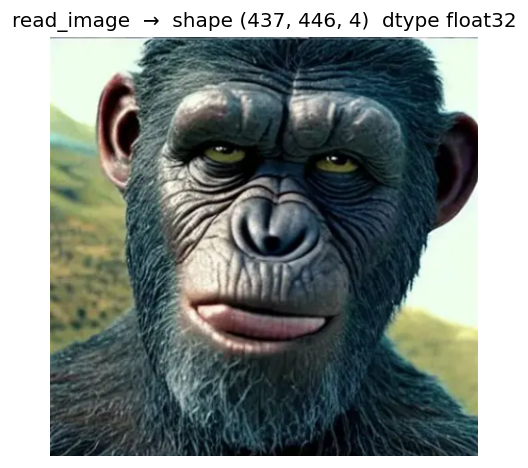

In [28]:
# ── 1. read_image ────────────────────────────────────────────────────
img = read_image(IMG_PATH)

print(f"shape  : {img.shape}")
print(f"dtype  : {img.dtype}")
print(f"min    : {img.min():.4f}")
print(f"max    : {img.max():.4f}")

plt.figure(figsize=(6, 4))
plt.imshow(img, cmap='gray' if img.ndim == 2 else None)
plt.title(f"read_image  →  shape {img.shape}  dtype {img.dtype}")
plt.axis('off')
plt.tight_layout()
plt.show()

shape  : (437, 446)
dtype  : float32


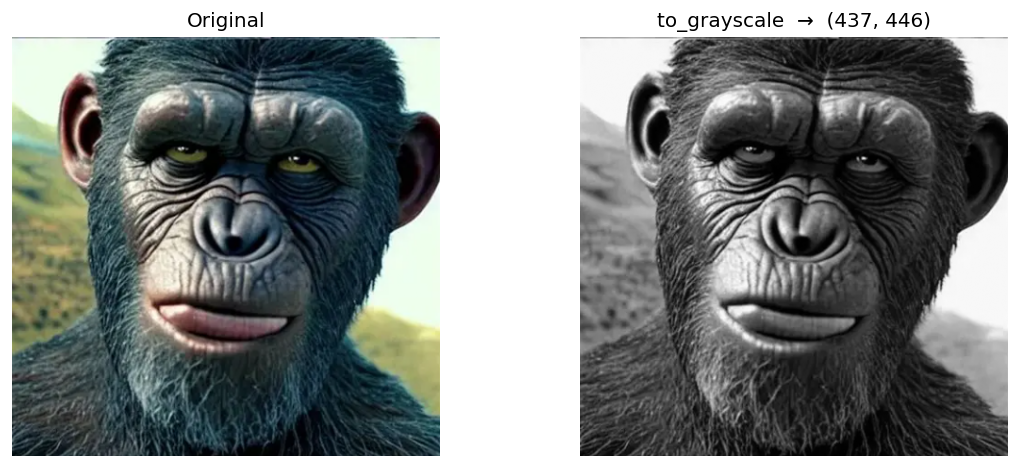

In [22]:
# ── 2. to_grayscale ──────────────────────────────────────────────────
gray = to_grayscale(img)

print(f"shape  : {gray.shape}")
print(f"dtype  : {gray.dtype}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img, cmap='gray' if img.ndim == 2 else None)
axes[0].set_title("Original")
axes[1].imshow(gray, cmap='gray')
axes[1].set_title(f"to_grayscale  →  {gray.shape}")
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# ── 3. to_rgb ───────────────────────────────────────────────────────
# For a grayscale input, to_rgb replicates the channel → (H, W, 3).
# For a BGR color input (OpenCV-style), pass src='bgr' (default)
# to swap B↔R and get correct RGB for Matplotlib display.

# Case A: grayscale → achromatic 3-channel (R=G=B)
rgb_from_gray = to_rgb(gray)               # gray is 2-D, src ignored

# Case B: simulate an OpenCV BGR image, then convert to RGB
img_bgr      = img[:, :, :3][:, :, ::-1].copy()   # flip channels → BGR
rgb_from_bgr = to_rgb(img_bgr)             # B↔R swap → RGB

print(f"gray → rgb_from_gray shape : {rgb_from_gray.shape}")
print(f"R==G==B (gray input)        : {np.allclose(rgb_from_gray[:,:,0], rgb_from_gray[:,:,1])}  (expected True)")
print(f"bgr  → rgb_from_bgr  shape : {rgb_from_bgr.shape}")
print(f"Matches original RGB        : {np.allclose(img[:,:,:3], rgb_from_bgr)}  (expected True)")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(gray, cmap='gray');   axes[0].set_title(f'Grayscale input\n{gray.shape}')
axes[1].imshow(rgb_from_gray);       axes[1].set_title(f'to_rgb(gray)\nachromatic {rgb_from_gray.shape}')
axes[2].imshow(rgb_from_bgr);        axes[2].set_title(f'to_rgb(bgr_image)\ncolors restored {rgb_from_bgr.shape}')
for ax in axes: ax.axis('off')
plt.suptitle('to_rgb — grayscale replication vs BGR→RGB conversion', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


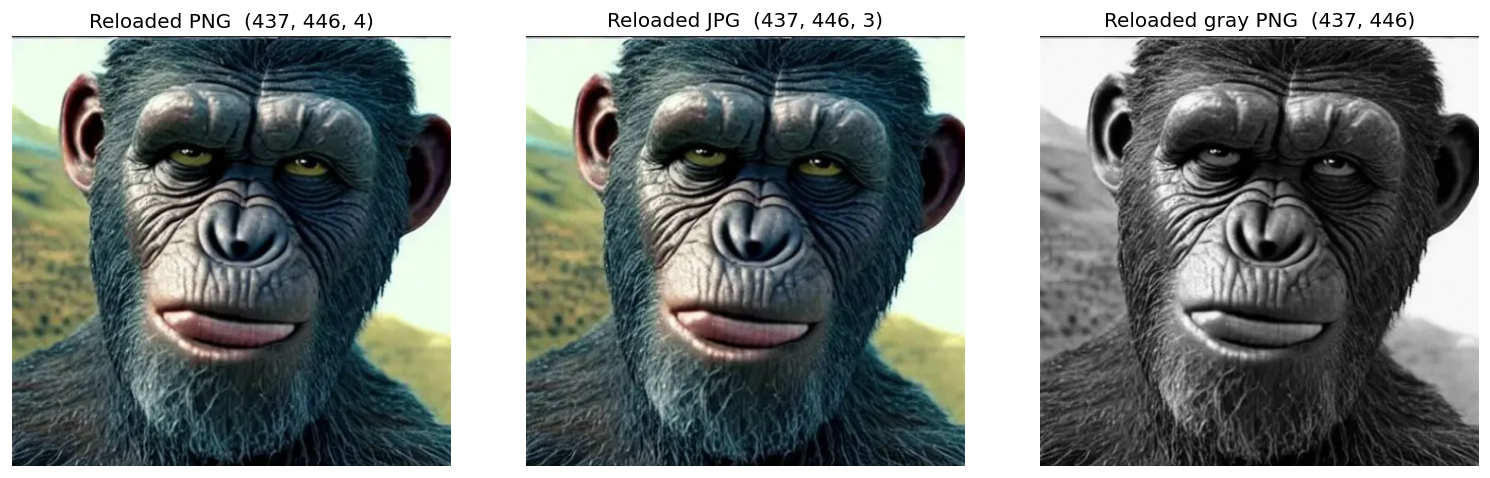

PNG  saved → D:\data ssd\machine vision\robovision_out_rgb.png
JPG  saved → D:\data ssd\machine vision\robovision_out_rgb.jpg
Gray saved → D:\data ssd\machine vision\robovision_out_gray.png


In [24]:
# ── 4. save_image then reload ────────────────────────────────────────
OUT_DIR = os.path.dirname(IMG_PATH)   # saves next to your input image

png_path  = os.path.join(OUT_DIR, "robovision_out_rgb.png")
jpg_path  = os.path.join(OUT_DIR, "robovision_out_rgb.jpg")
gray_path = os.path.join(OUT_DIR, "robovision_out_gray.png")

save_image(img,  png_path)
save_image(img,  jpg_path, quality=90)
save_image(gray, gray_path)

reload_png  = read_image(png_path)
reload_jpg  = read_image(jpg_path)
reload_gray = read_image(gray_path, as_gray=True)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(reload_png[:,:,:3]);  axes[0].set_title(f"Reloaded PNG  {reload_png.shape}")
axes[1].imshow(reload_jpg);          axes[1].set_title(f"Reloaded JPG  {reload_jpg.shape}")
axes[2].imshow(reload_gray, cmap='gray'); axes[2].set_title(f"Reloaded gray PNG  {reload_gray.shape}")
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

print(f"PNG  saved → {png_path}")
print(f"JPG  saved → {jpg_path}")
print(f"Gray saved → {gray_path}")

In [25]:
# ── 5. Error handling ────────────────────────────────────────────────
tests = [
    (lambda: read_image(123),                   TypeError,       "read_image(123)"),
    (lambda: read_image("no_such_file.png"),    FileNotFoundError, "read_image missing file"),
    (lambda: save_image(img, "out.bmp"),        ValueError,      "save_image bad extension"),
    (lambda: to_grayscale(np.zeros((4,4,5))),   ValueError,      "to_grayscale bad channels"),
    (lambda: to_grayscale("not_an_array"),      TypeError,       "to_grayscale wrong type"),
]

all_ok = True
for fn, expected_exc, label in tests:
    try:
        fn()
        print(f"  ❌ FAIL  {label}  — no exception raised")
        all_ok = False
    except expected_exc as e:
        print(f"  ✅ OK    {label}")
        print(f"           → {e}")
    except Exception as e:
        print(f"  ⚠️  WRONG EXC  {label}  — got {type(e).__name__}: {e}")
        all_ok = False

print()
print("All error tests passed ✅" if all_ok else "Some tests FAILED ❌")

  ✅ OK    read_image(123)
           → 'path' must be a str, got int.
  ✅ OK    read_image missing file
           → No file found at path: 'no_such_file.png'. Check spelling and that the file exists.
  ✅ OK    save_image bad extension
           → Unsupported file extension '.bmp'. Supported formats: .png, .jpg, .jpeg
  ✅ OK    to_grayscale bad channels
           → 'image' must be shaped (H, W) or (H, W, C) with C ∈ {1, 3, 4}, got shape (4, 4, 5).
  ✅ OK    to_grayscale wrong type
           → 'image' must be a NumPy ndarray, got str.

All error tests passed ✅


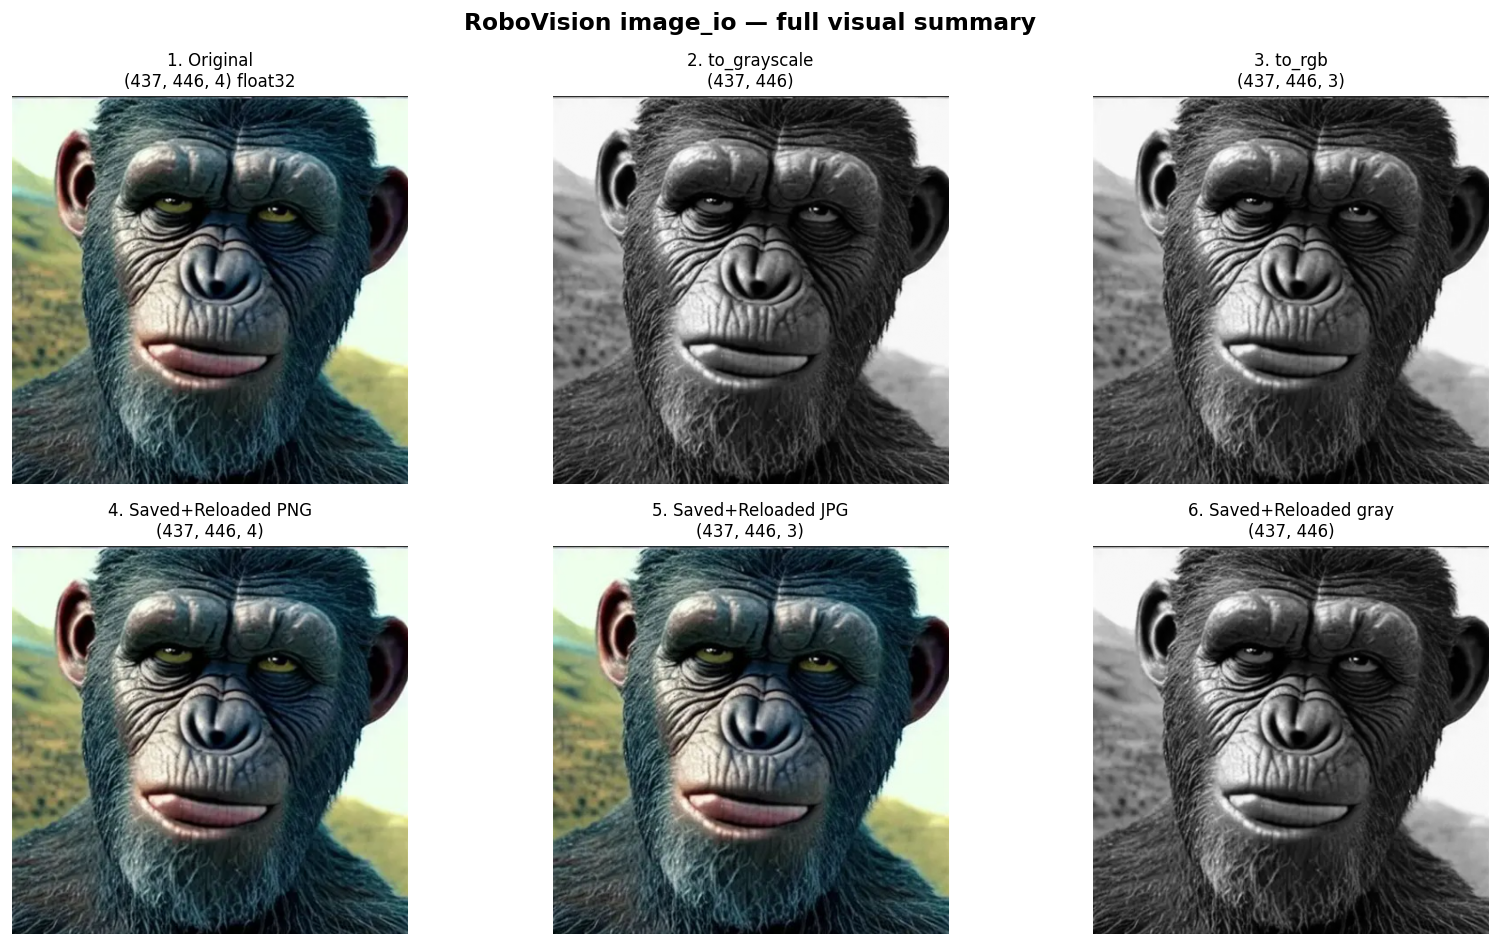


🎉 All done!


In [26]:
# ── 6. Full summary panel ────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle("RoboVision image_io — full visual summary", fontsize=14, fontweight='bold')

panels = [
    (img,                  'gray' if img.ndim==2 else None, f"1. Original\n{img.shape} float32"),
    (gray,                 'gray',                          f"2. to_grayscale\n{gray.shape}"),
    (rgb_from_gray,        None,                            f"3. to_rgb\n{rgb_from_gray.shape}"),
    (reload_png[:,:,:3],   None,                            f"4. Saved+Reloaded PNG\n{reload_png.shape}"),
    (reload_jpg,           None,                            f"5. Saved+Reloaded JPG\n{reload_jpg.shape}"),
    (reload_gray,          'gray',                          f"6. Saved+Reloaded gray\n{reload_gray.shape}"),
]

for ax, (data, cmap, title) in zip(axes.flat, panels):
    ax.imshow(data, cmap=cmap)
    ax.set_title(title, fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()
print("\n🎉 All done!")